In [ ]:
#Imports

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import sklearn

2026-02-24 13:22:46.790090: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 13:22:47.008386: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 13:22:48.053490: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"X_train: {}") # 50000, 32, 32, 3
print(f"y_train: {}") # 50000, 1
print(f"X_test: {}")   # 10000, 32, 32, 3
print(f"y_test: {}")   # 10000, 1

X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [ ]:
lbls = ['Airplane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog',
                'Frog', 'Horse', 'Ship', 'Truck']

fig, axes = plt.subplots(5,5, figsize = (10,10))
axes = axes.ravel() 
for i in range(0, xxx): #We want to loop through all elements in the subplot
    idx = np.random.randint(0, xxx) #select a random index in the entirety of the train dataset
    axes[xxx].imshow(X_train[xxx,1:]) # show the image in the appropriate place in the subplot
    lbl_idx = int(y_train[xxx]) # Retrieve the label of the selected index
    axes[xxx].set_title(lbls[xxx], fontsize = 8) # Use the index label to get the proper label name
    axes[xxx].axis('off') # We remove axis for better image clarity

plt.subplots_adjust(hspace=0.4)

NameError: name 'plt' is not defined

Text(0.5, 1.0, 'Class distribution in training set')

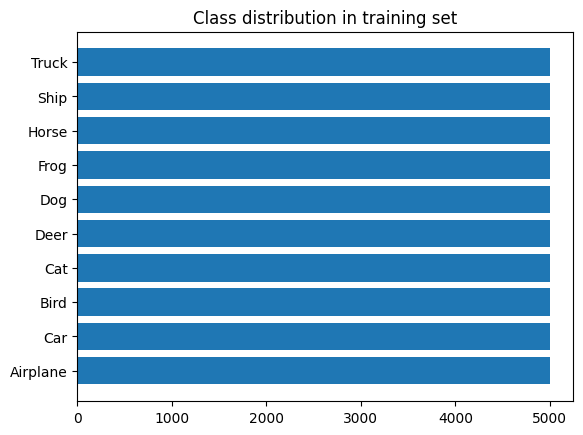

In [ ]:
classes, counts = np.unique(y_train, xxx) #find the proper parameter to get the counts
plt.barh(xxx, xxx) # We want to print an histogram type barplot of all the labels with their counts 
plt.title('Class distribution in training set')

In [ ]:
X_train = X_train / xxx
X_test = X_test / xxx

In [10]:
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
X_TRAIN, X_VAL, Y_TRAIN, Y_VAL = train_test_split() #Use 20% in the val split, make sure to use y_train_cat

In [ ]:
## NEtwork parts to use :
layers.Conv2D(filters=xxx, kernel_size=(3, 3), input_shape=INPUT_SHAPE, activation='relu', padding='same')
layers.BatchNormalization()
layers.MaxPool2D(pool_size=(2, 2))
layers.Dropout(0.25)
layers.Flatten()
layers.Dense(units = xxx, activation=xxx)

In [ ]:
INPUT_SHAPE = (xxx,xxx,xxx)

model = keras.Sequential()
model.add() # add everything you want to the model, these will be your layers, we can expect 10 to 15 layers

layers.Dense(units = 10, activation='softmax') # This one has to be the last layer
model.summary()

NameError: name 'xxx' is not defined

In [ ]:
model.compile(loss='categorical_crossentropy',  optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model.fit(X_TRAIN,Y_TRAIN, 
                    epochs=xxx, batch_size = xxx,
                    validation_data=(X_VAL, Y_VAL), verbose = 1,
                    # callbacks = []
                    )

In [ ]:
plt.figure(figsize=(12, 16))

plt.subplot(4, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='val_Loss')
plt.title('Loss')
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.legend()

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

con = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=lbls)

fig, ax = plt.subplots(figsize=(10, 10))
con = con.plot(xticks_rotation='vertical', ax=ax,cmap='summer')

plt.show()

In [ ]:
import random
idx = random.randint(0, len(X_test))
im = X_test[idx]
plt.imshow(im)

pred_t = np.argmax(model.predict(im.reshape(1, 32, 32, 3)))
print(f"our model predicts that image {idx} is {lbls[pred_t]}")